# Chuẩn bị

**Cài đặt các Thư viện sử dụng**

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from underthesea import word_tokenize
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [ ]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt dataFrame**

In [ ]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**


In [ ]:
file = os.path.join("../../Data_Train", "English.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

# Khám phá dữ liệu

**Xem thông tin dữ liệu**

In [ ]:
data_df.sample(5)

**Mô tả của dữ liệu**

In [ ]:
data_df.info()

In [ ]:
data_df.describe().round(1)

**Kích thước của DataFrame và danh sách các tên cột**

In [ ]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [ ]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

**Kiểm tra dữ liệu có bị lặp**

In [ ]:
dup=data_df.index.duplicated().sum()
dup

**Kiểm tra dữ liệu có bị thiếu**

In [ ]:
data_df['title'].isnull().sum()

In [ ]:
data_df['text'].isnull().sum()

In [ ]:
data_df['label'].isnull().sum()

**Kiểm tra loại dữ liệu**

In [ ]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [ ]:
open_object_dtype(data_df['title'])

In [ ]:
open_object_dtype(data_df['text'])

In [ ]:
open_object_dtype(data_df['label'])

**Kiểm tra số từ của title và text**

In [ ]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [ ]:
data_df[["title_length", "text_length"]].describe()

In [ ]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

In [ ]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [ ]:
len_title_sum=0

for i in data_df['title']:
    len_title_sum+=len(i)

avg_title=len_title_sum/data_df['title'].count()

avg_title

**Độ dài lớn nhất của tiêu đề**

In [ ]:
max_title_len=0

for i in data_df['title']:
    if len(i)>max_title_len:
        max_title_len=len(i)

max_title_len

**Độ dài nhỏ nhất của tiêu đề**

In [ ]:
min_title_len=max_title_len

for i in data_df['title']:
    if len(i) < min_title_len:
        min_title_len=len(i)

min_title_len

**Chiều dài trung bình text của 1 tin tức**

In [ ]:
len_text_sum=0

for i in data_df['text']:
    len_text_sum+=len(i)

avg_text=len_text_sum/data_df['text'].count()

avg_text

**Độ dài lớn nhất của text**

In [ ]:
max_text_len=0

for i in data_df['text']:
    if len(i)>max_text_len:
        max_text_len=len(i)

max_text_len

**Độ dài nhỏ nhất của text**

In [ ]:
min_text_len=max_text_len

for i in data_df['text']:
    if len(i) < min_text_len:
        min_text_len=len(i)

min_text_len

# Tiền xử lí văn bản

**Tạo stopword**

In [ ]:
import nltk
from nltk.corpus import stopwords

# Tải stopwords từ NLTK nếu chưa tải
# nltk.download('stopwords')

# Sử dụng danh sách từ dừng (stopwords) của tiếng Anh từ NLTK
stopword_list = list(stopwords.words('english'))
stopwords = [word for word in stopword_list if word.strip() != '']


**Loại bỏ các đường link và các dấu câu, lowercase**

In [ ]:
import string
def wordopt(text):
    text=re.sub("Reuters"," ",text)

    update_text =""

    text = text.lower()

    text=re.sub("reuters"," ",text)
    
    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"\'ll"," will",text)
    text=re.sub(r"\'ve"," have",text)
    text=re.sub(r"\'re"," are",text)
    text=re.sub(r"\'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)


    text=re.sub(r"[-()\"#!@$%^&*{}?.,:]"," ",text)
    text=re.sub(r"\s+"," ",text)

    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W", " ", text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)

    for word in text.split():
        if word not in stopwords:
            update_text += word+" "
    
    return update_text.strip()


**Hợp nhất title và text**

In [ ]:
data_df['article'] = ' |title| '+ data_df["title"] +' |text| '+  data_df["text"] 

In [ ]:
data_df.head(1)

**Áp dụng các xử lý dữ liệu**

In [ ]:
data_df['Compound_Content_SW'] = data_df['article'].apply(wordopt)

In [ ]:
data_df.head(1)

# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [ ]:
def tokenize(sentence):
    return word_tokenize(sentence, format = 'word')

**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [ ]:
X = data_df["Compound_Content_SW"]
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [ ]:
model_vector_CV = os.path.join("../../Vector/English/CV", "English_vectorizer_CV.joblib")
model_RFC_CV = os.path.join("../../Vector/English/CV", "English_RFC_model_CV.joblib")


In [ ]:
model_vector_TF = os.path.join("../../Vector/English/TF", "English_vectorizer_TF.joblib")
model_RFC_TF = os.path.join("../../Vector/English/TF", "English_RFC_model_TF.joblib")

In [ ]:
model_vector_W2V = os.path.join("../../Vector/English/W2V", "English_vectorizer_W2V.joblib")
model_RFC_W2V = os.path.join("../../Vector/English/W2V", "English_RFC_model_W2V.joblib")

In [ ]:
model_vector_D2V = os.path.join("../../Vector/English/D2V", "English_vectorizer_D2V.joblib")
model_RFC_D2V = os.path.join("../../Vector/English/D2V", "English_RFC_model_D2V.joblib")

## Các mô hình vector 

**CountVectorizer**

In [ ]:
vectorizerCV = CountVectorizer(
    stop_words = stopwords,
    tokenizer = tokenize,
)

In [ ]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

**TfidfVectorizer**

In [ ]:
vectorizerTF = TfidfVectorizer(max_features=50000, stop_words=stopwords, min_df=0.002, max_df=0.5, 
                                   use_idf=True, ngram_range=(1,3))

In [ ]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

**Word2Vec**

In [ ]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [ ]:
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=10
)

In [ ]:
# Function to calculate the average Word2Vec vector for each sentence
def sentence_vector(sentence, model):
    # Get vectors for words in the sentence if they exist in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        # Calculate the mean of the word vectors for the sentence
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words in the sentence are in the vocabulary
        return np.zeros(model.vector_size)

In [ ]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

**Doc2Vec**

In [ ]:
documents = [TaggedDocument(doc.split(), [i]) for i, doc in enumerate(X_train)]

In [ ]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [ ]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_test]

## Save model

In [ ]:
# joblib.dump(vectorizerCV, model_vector_CV)
# joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

# Bước 1: Thuật toán RFC

## Áp dụng các cách vector với RFC

In [ ]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

**CountVectorizer**

In [ ]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

**tfidfVectorizer**

In [ ]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

**Word2Vec**

In [ ]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

**Doc2Vec**

In [ ]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

## Đánh giá mô hình

**Vẽ hình**

In [ ]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

In [ ]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

**Tính toán đánh giá**

In [120]:
def evaluate_model(y_true, y_pred, name_model, save=False):

    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }
    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/English", f"English_Evaluate_{name_model}.csv")
        
        metrics_df.to_csv(path_evaluate, index=False)

## Kết quả các model

**CountVectorizer**

0.9832820512820513
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4879
           1       0.98      0.98      0.98      4871

    accuracy                           0.98      9750
   macro avg       0.98      0.98      0.98      9750
weighted avg       0.98      0.98      0.98      9750

-------------------



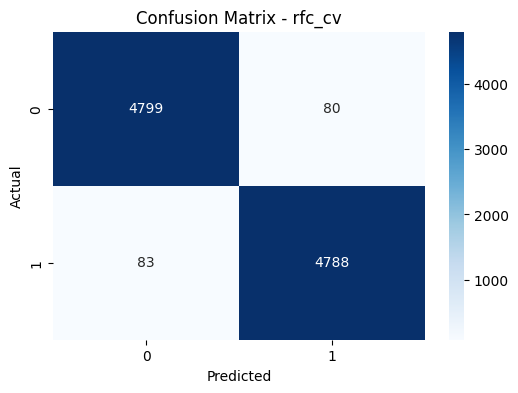

In [121]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv",save=True)

**TfidfVectorizer**

0.9894358974358974
-------------------

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4879
           1       0.99      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



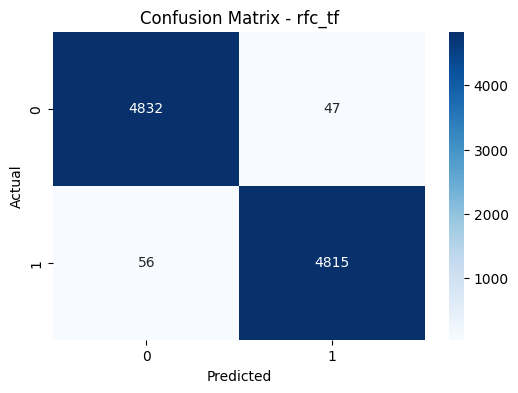

In [122]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf",save=True)

**Word2Vec**

0.9626666666666667
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4879
           1       0.96      0.96      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750

-------------------



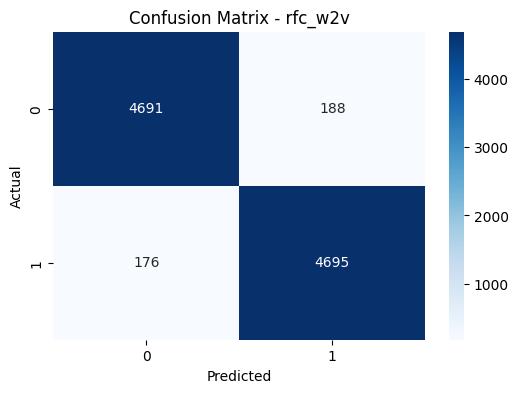

In [123]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v",save=True)


**Doc2Vec**

0.9382564102564103
-------------------

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      4879
           1       0.93      0.95      0.94      4871

    accuracy                           0.94      9750
   macro avg       0.94      0.94      0.94      9750
weighted avg       0.94      0.94      0.94      9750

-------------------



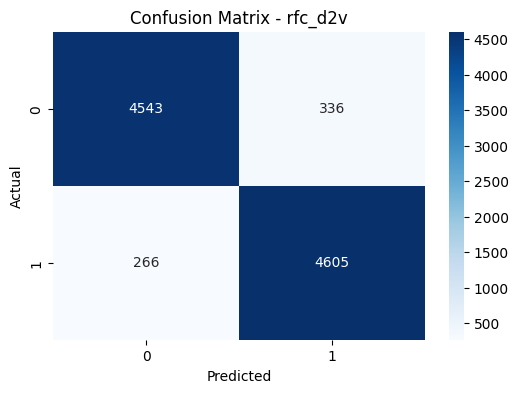

In [124]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v",save=True)

*Save model RFC*

In [125]:
# joblib.dump(rfc_cv, model_RFC_CV)
# joblib.dump(rfc_tf, model_RFC_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(rfc_d2v, model_RFC_D2V)

# Bước 2:Vector hóa TF-IDF

## Navie bayes

In [126]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)

0.9563076923076923
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4879
           1       0.96      0.96      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750

-------------------



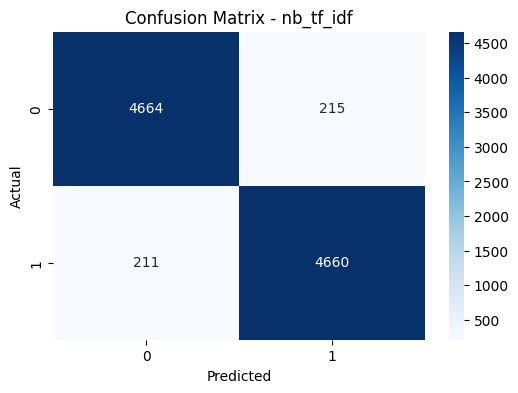

In [127]:
accuracy = accuracy_score(y_test, y_pred_nb) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_nb))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_nb,name_model="nb_tf_idf")

## Decision Tree

In [128]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)

0.9596923076923077
-------------------

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      4879
           1       0.95      0.97      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750

-------------------



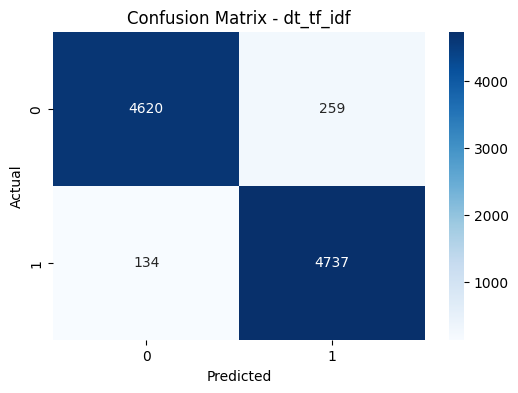

In [129]:
accuracy = accuracy_score(y_test, y_pred_dt) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_dt))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_dt,name_model="dt_tf_idf")

## RandomForest

In [130]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)

0.9894358974358974
-------------------

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4879
           1       0.99      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



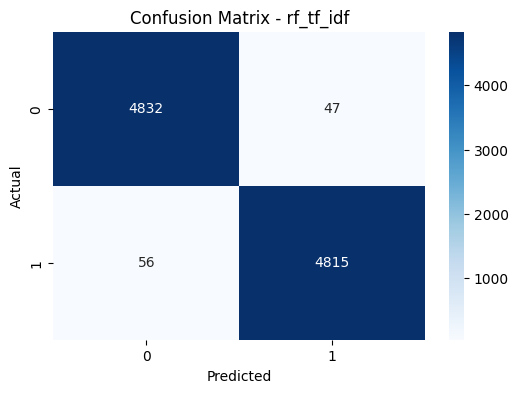

In [131]:
accuracy = accuracy_score(y_test, y_pred_rf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_rf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_rf,name_model="rf_tf_idf")

## SVM

In [132]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)

0.9934358974358974
-------------------

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4879
           1       1.00      0.99      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



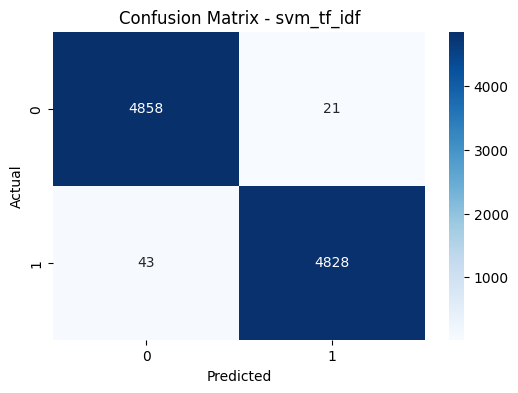

In [133]:
accuracy = accuracy_score(y_test, y_pred_svm) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_svm))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_svm,name_model="svm_tf_idf")

## LogisticRegression

In [134]:
lr_model = LogisticRegression()
lr_model.fit(Xv_trainTF, y_train)
y_pred_lr = lr_model.predict(Xv_testTF)


0.9865641025641025
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4879
           1       0.99      0.98      0.99      4871

    accuracy                           0.99      9750
   macro avg       0.99      0.99      0.99      9750
weighted avg       0.99      0.99      0.99      9750

-------------------



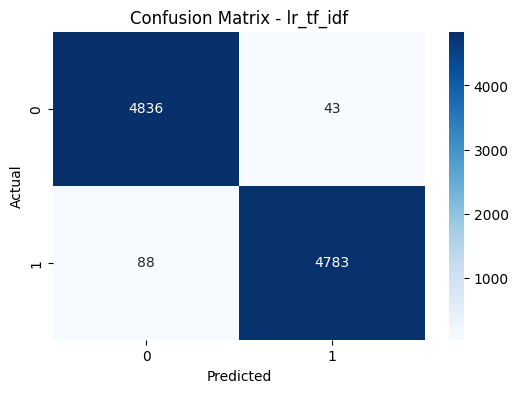

In [135]:
accuracy = accuracy_score(y_test, y_pred_lr) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_lr))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_lr,name_model="lr_tf_idf")

## GradientBoostingClassifier

In [136]:
gbc_model = GradientBoostingClassifier(random_state=0)
gbc_model.fit(Xv_trainTF, y_train)
y_pred_gbc = gbc_model.predict(Xv_testTF)

0.9714871794871794
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      4879
           1       0.98      0.96      0.97      4871

    accuracy                           0.97      9750
   macro avg       0.97      0.97      0.97      9750
weighted avg       0.97      0.97      0.97      9750

-------------------



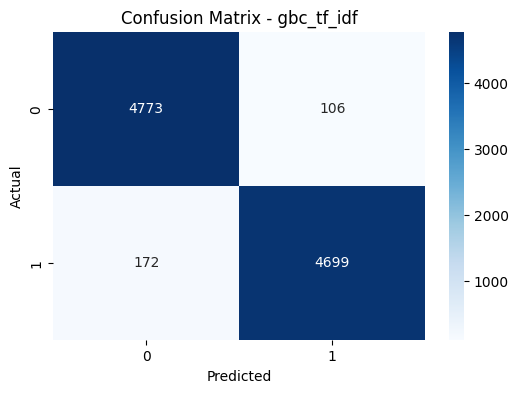

In [137]:
accuracy = accuracy_score(y_test, y_pred_gbc) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_gbc,name_model="gbc_tf_idf")